In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
from pynwb import NWBHDF5IO

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox
from sklearn.metrics import classification_report

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
from markov_phoneme_model import MarkovPhonemeModel

In [2]:
feature_extraction_method = 'high_gamma' #'multi_band' 

In [3]:
# Define paths
path_bids = './SingleWordProductionDutch-iBIDS'
path_output = './features'
path_results = './results'

# Create directories if they don't exist
os.makedirs(path_output, exist_ok=True)
os.makedirs(path_results, exist_ok=True)

In [4]:
# Initialize the custom decoder
custom_decoder = CustomBrainAudioDecoder(
        path_bids=path_bids,
        path_output=path_output,
        path_results=path_results,
        debug_mode=True
    )

CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=True
CustomBrainAudioDecoder [DEBUG]: Initialized additional models for comparison


In [5]:
print("Stratifying participants...")
participant_strata = custom_decoder.stratify_participants_by_channel_quality(
        channel_correlation_threshold=0.1
    )

Stratifying participants...
CustomBrainAudioDecoder [DEBUG]: Stratifying participants based on channel quality...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-01...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-02...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-03...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-04...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-05...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-06...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-07...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-08...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-09...
CustomBrainAudioDecoder [DEBUG]: Analyzing channels for sub-10...
CustomBrainAudioDecoder: 
Participant stratification results:
CustomBrainAudioDecoder:   Participants with most relevant channels: 3
CustomBrainAudioDecoder:   Participants with relevant channels: 4
CustomBrainAudioDecoder:   

In [6]:
# Create train/test split
split_result = custom_decoder.create_stratified_cross_word_split(
    participant_strata=participant_strata,
    test_ratio=0.2,
    min_word_freq=1,
    random_seed=42
)

CustomBrainAudioDecoder: Segmenting data for sub-06...
CustomBrainAudioDecoder [DEBUG]: Segmenting data by words for sub-06...
CustomBrainAudioDecoder [DEBUG]: Loaded 307594 word markers
CustomBrainAudioDecoder [DEBUG]: First 10 word markers: ['hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe' 'hoe']
CustomBrainAudioDecoder [DEBUG]: Found 100 word onsets
CustomBrainAudioDecoder [DEBUG]: First 5 word onsets: [(0, 'hoe'), (3077, 'zevenduizend'), (6152, 'en'), (9228, 'het'), (12302, 'smeekte')]
CustomBrainAudioDecoder [DEBUG]: Found 100 unique words with at least 1 occurrences
CustomBrainAudioDecoder [DEBUG]: Word 'hoe': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'zevenduizend': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'en': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'het': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'smeekte': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word statistics:
CustomBrainAudioDecoder [DEBUG]:   Total unique words: 100
CustomBrai

CustomBrainAudioDecoder [DEBUG]: Loaded 307579 word markers
CustomBrainAudioDecoder [DEBUG]: First 10 word markers: ['de' 'de' 'de' 'de' 'de' 'de' 'de' 'de' 'de' 'de']
CustomBrainAudioDecoder [DEBUG]: Found 100 word onsets
CustomBrainAudioDecoder [DEBUG]: First 5 word onsets: [(0, 'de'), (3076, 'buurt'), (6153, 'verstijfde'), (9231, 'zonlicht'), (12307, 'zevenduizend')]
CustomBrainAudioDecoder [DEBUG]: Found 100 unique words with at least 1 occurrences
CustomBrainAudioDecoder [DEBUG]: Word 'de': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'buurt': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'verstijfde': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'zonlicht': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word 'zevenduizend': 1 instances
CustomBrainAudioDecoder [DEBUG]: Word statistics:
CustomBrainAudioDecoder [DEBUG]:   Total unique words: 100
CustomBrainAudioDecoder [DEBUG]:   Total word instances: 100
CustomBrainAudioDecoder [DEBUG]: 
Overlap statistics:
CustomBrainA

In [7]:
# Initialize detector
detector = AcousticChangeDetector(
    min_segment_duration=0.03,
    max_segment_duration=0.3,
    distance_metric='cosine',
    smoothing_window=3,
    peak_threshold=0.5,
    decoder=custom_decoder,
    debug_mode=False
)
detector.split_result = split_result

AcousticChangeDetector: Initialized with DEBUG_MODE=False


In [8]:
print("Accumulating training data...")
train = detector.accumulate_phoneme_data(
    num_batches=5,
    batch_size=32,
    feature_extraction_method = feature_extraction_method,
    batch_type='train'
)

Accumulating training data...
AcousticChangeDetector: Accumulating train data from 5 batches...
AcousticChangeDetector: Processing batch 1/5
AcousticChangeDetector: Accumulated 32 phoneme segments so far
AcousticChangeDetector: Processing batch 2/5
AcousticChangeDetector: Accumulated 64 phoneme segments so far
AcousticChangeDetector: Processing batch 3/5
AcousticChangeDetector: Accumulated 96 phoneme segments so far
AcousticChangeDetector: Processing batch 4/5
AcousticChangeDetector: Accumulated 128 phoneme segments so far
AcousticChangeDetector: Processing batch 5/5
AcousticChangeDetector: Accumulated 160 phoneme segments so far
AcousticChangeDetector: Accumulated data from 5 batches:
AcousticChangeDetector: Total phoneme segments: 160
AcousticChangeDetector: Unique phonemes: 36


In [9]:
test = detector.accumulate_phoneme_data(
    num_batches=3,
    batch_size=32,
    feature_extraction_method = feature_extraction_method,
    batch_type='test'
)

AcousticChangeDetector: Accumulating test data from 3 batches...
AcousticChangeDetector: Processing batch 1/3
AcousticChangeDetector: Accumulated 32 phoneme segments so far
AcousticChangeDetector: Processing batch 2/3
AcousticChangeDetector: Accumulated 64 phoneme segments so far
AcousticChangeDetector: Processing batch 3/3
AcousticChangeDetector: Accumulated 96 phoneme segments so far
AcousticChangeDetector: Accumulated data from 3 batches:
AcousticChangeDetector: Total phoneme segments: 96
AcousticChangeDetector: Unique phonemes: 26


In [10]:
validator = PhonemeValidator(detector=detector)
validator.enable_debug()

PhonemeValidator: Initialized with DEBUG_MODE=False
PhonemeValidator: Debug mode enabled


In [11]:
# Resolve training data
if train['phoneme_labels'].count('?') > 0:
    train_converted = {
        'phoneme_labels': train['phoneme_labels'],
        'phoneme_spectrogram_segments': train.get('spectrograms', []),
        'phoneme_words': train['phoneme_words'],
        'phoneme_positions': train.get('phoneme_positions', [0] * len(train['phoneme_labels'])),
        'phoneme_participant_ids': train.get('phoneme_participant_ids', ['unknown'] * len(train['phoneme_labels']))
    }
    
    resolved_train = validator.resolve_unknown_phonemes(train_converted)
    train['phoneme_labels'] = resolved_train['phoneme_labels']
    print(f"\nTraining after resolution: {train['phoneme_labels'].count('?')} unknown phonemes")

PhonemeValidator [DEBUG]: Attempting to resolve 32 unknown phonemes
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'maantje' as 'm'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'of' as 'ɔf'
PhonemeValidator [DEBUG]: Resolved p

In [12]:
# Resolve test data
if test['phoneme_labels'].count('?') > 0:
    test_converted = {
        'phoneme_labels': test['phoneme_labels'],
        'phoneme_spectrogram_segments': test.get('spectrograms', []),
        'phoneme_words': test['phoneme_words'],
        'phoneme_positions': test.get('phoneme_positions', [0] * len(test['phoneme_labels'])),
        'phoneme_participant_ids': test.get('phoneme_participant_ids', ['unknown'] * len(test['phoneme_labels']))
    }
    
    resolved_test = validator.resolve_unknown_phonemes(test_converted)
    test['phoneme_labels'] = resolved_test['phoneme_labels']
    print(f"Test after resolution: {test['phoneme_labels'].count('?')} unknown phonemes")

PhonemeValidator [DEBUG]: Attempting to resolve 26 unknown phonemes
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'dichtbij' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'aan' as 'a'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'aan' as 'a'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'aan' as 'a'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'direct' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'direct' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'direct' as 'd'
PhonemeValidator [DEBUG]: Resolved phoneme at position 0 in 'direct' as 'd'
PhonemeValidator [D

In [13]:
# Check if your features have actual variance
for i in range(min(5, len(train['features']))):
    feat = train['features'][i]
    print(f"Feature {i} shape: {feat.shape}, mean: {np.mean(feat):.6f}, std: {np.std(feat):.6f}")

# If std is near zero, your features are flat - check the extraction

Feature 0 shape: (295, 50), mean: 0.000000, std: 1.540018
Feature 1 shape: (295, 50), mean: -0.000000, std: 1.563018
Feature 2 shape: (295, 50), mean: 0.000000, std: 1.523640
Feature 3 shape: (295, 50), mean: -0.000000, std: 1.554453
Feature 4 shape: (295, 50), mean: 0.000000, std: 1.480349


In [14]:
total_words = sum(len(participant_data) for participant_data in detector.split_result['train'].values())
total_test_words = sum(len(participant_data) for participant_data in detector.split_result['test'].values())
print(f"Total training words: {total_words}, Total test words: {total_test_words}")

Total training words: 790, Total test words: 205


In [15]:
# 3. Add phoneme groups to PhoneticDictionary
phonetic_dict = detector.phonetic_dict
if not hasattr(phonetic_dict, 'phoneme_groups'):
    phonetic_dict.add_phoneme_groups()
    
# 4. Map phonemes to phoneme groups
print("Mapping phonemes to phoneme groups")
train_group_labels = [phonetic_dict.get_phoneme_group(p) or 'unknown' for p in train['phoneme_labels']]
test_group_labels = [phonetic_dict.get_phoneme_group(p) or 'unknown' for p in test['phoneme_labels']] 

Mapping phonemes to phoneme groups


In [16]:
print("\n" + "="*60)
print("MARKOV CHAIN MODEL TRAINING")
print("="*60)

# Initialize Markov model with your phonetic dictionary
markov_model = MarkovPhonemeModel(
    phonetic_dict = phonetic_dict,
    order = 2,  # Trigram model (looks at 2 previous phonemes)
    output_dir = os.path.join(path_results, 'markov_model'),
    debug_mode=True
)


MARKOV CHAIN MODEL TRAINING
MarkovPhonemeModel: Initialized MarkovPhonemeModel with order=2


In [17]:
# Filter out most "unknown" samples during training
filtered_features = []
filtered_labels = []
filtered_words = []
filtered_participants = []  # Add this!

for i, label in enumerate(train['phoneme_labels']):
    group = markov_model.phoneme_to_group.get(label, 'unknown')
    
    # Keep all non-unknown, but only keep 10% of unknown
    if group != 'unknown' or np.random.random() < 0.1:
        filtered_features.append(train['features'][i])
        filtered_labels.append(label)
        filtered_words.append(train['phoneme_words'][i])
        filtered_participants.append(train['phoneme_participant_ids'][i])  

In [18]:
# Train the Markov model
print("\nTraining Markov model...")
markov_training_results = markov_model.train(
    features            = filtered_features,
    phoneme_labels      = filtered_labels,
    words               = filtered_words,  # Important for learning word-internal transitions
    participant_ids     = filtered_participants
)

print(f"Training with {len(filtered_features)} samples (filtered from {len(train['features'])})")


Training Markov model...
MarkovPhonemeModel: Training Markov chain model...
MarkovPhonemeModel: Mapping phonemes to groups...
MarkovPhonemeModel: Training on 8 classes: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Group distribution: {'alveolar': 43, 'labial': 17, 'front_vowels': 19, 'glottal': 7, 'back_vowels': 27, 'palatal': 12, 'dorsal': 7, 'unknown': 2}
MarkovPhonemeModel: Building transition model...
MarkovPhonemeModel: Built transition model with 26 contexts
MarkovPhonemeModel: Building acoustic model...
MarkovPhonemeModel: Training on groups: ['alveolar', 'back_vowels', 'dorsal', 'front_vowels', 'glottal', 'labial', 'palatal', 'unknown']
MarkovPhonemeModel: Trained acoustic model on 134 samples with 8 groups
MarkovPhonemeModel: Building initial state probabilities...
MarkovPhonemeModel: Built initial probabilities for 8 states
MarkovPhonemeModel: Model saved to ./results\markov_model\markov_model.pkl
Traini

In [19]:
# Check what the model learned
from collections import Counter

# Get some predictions with probabilities
sample_features = markov_model.feature_scaler.transform(
    np.array([np.mean(f, axis=0) if f.ndim > 1 else f for f in test['features'][:10]])
)
sample_probs = markov_model.acoustic_classifier.predict_proba(sample_features)

print("Sample prediction probabilities:")
for i in range(3):
    print(f"Sample {i}:")
    for j, class_name in enumerate(markov_model.group_encoder.classes_):
        print(f"  {class_name}: {sample_probs[i, j]:.3f}")

Sample prediction probabilities:
Sample 0:
  alveolar: 0.203
  back_vowels: 0.165
  dorsal: 0.073
  front_vowels: 0.247
  glottal: 0.060
  labial: 0.151
  palatal: 0.066
  unknown: 0.035
Sample 1:
  alveolar: 0.148
  back_vowels: 0.180
  dorsal: 0.075
  front_vowels: 0.183
  glottal: 0.072
  labial: 0.123
  palatal: 0.127
  unknown: 0.093
Sample 2:
  alveolar: 0.148
  back_vowels: 0.147
  dorsal: 0.095
  front_vowels: 0.151
  glottal: 0.103
  labial: 0.136
  palatal: 0.123
  unknown: 0.096


In [20]:
# evaluate the markov model
# Evaluate without Viterbi
try:
    eval_independent = markov_model.evaluate(
        features=test['features'],
        true_labels=test['phoneme_labels'],
        use_viterbi=False
    )
    print(f"Independent predictions accuracy: {eval_independent['accuracy']:.4f}")
except Exception as e:
    print(f"Error in independent evaluation: {e}")
    eval_independent = None

# Evaluate with Viterbi
try:
    eval_viterbi = markov_model.evaluate(
        features=test['features'],
        true_labels=test['phoneme_labels'],
        use_viterbi=True
    )
    print(f"Viterbi decoding accuracy: {eval_viterbi['accuracy']:.4f}")
except Exception as e:
    print(f"Error in Viterbi evaluation: {e}")
    eval_viterbi = None

MarkovPhonemeModel [DEBUG]: First classifier prediction: 3
MarkovPhonemeModel: First 10 comparisons:
MarkovPhonemeModel:   0: True='alveolar' vs Pred='front_vowels' -> False
MarkovPhonemeModel:   1: True='palatal' vs Pred='front_vowels' -> False
MarkovPhonemeModel:   2: True='front_vowels' vs Pred='front_vowels' -> True
MarkovPhonemeModel:   3: True='glottal' vs Pred='back_vowels' -> False
MarkovPhonemeModel:   4: True='front_vowels' vs Pred='palatal' -> False
MarkovPhonemeModel:   5: True='alveolar' vs Pred='labial' -> False
MarkovPhonemeModel:   6: True='alveolar' vs Pred='back_vowels' -> False
MarkovPhonemeModel:   7: True='back_vowels' vs Pred='alveolar' -> False
MarkovPhonemeModel:   8: True='alveolar' vs Pred='unknown' -> False
MarkovPhonemeModel:   9: True='back_vowels' vs Pred='back_vowels' -> True
Independent predictions accuracy: 0.1771
MarkovPhonemeModel [DEBUG]: First classifier prediction: 3
MarkovPhonemeModel: First 10 comparisons:
MarkovPhonemeModel:   0: True='alveolar'

In [21]:
# results by phoneme group
if eval_viterbi is not None:
    print("\n" + "="*60)
    print("PERFORMANCE BY PHONEME GROUP")
    print("="*60) 

    
    # Get the group labels
    true_groups = eval_viterbi['true_groups']
    pred_groups = eval_viterbi['predicted_groups']
    
    # Generate classification report
    report = classification_report(
        true_groups, 
        pred_groups,
        target_names=list(markov_model.group_encoder.classes_),
        output_dict=True
    )
    
    # Print performance for each group
    for group in markov_model.group_encoder.classes_:
        if group in report:
            metrics = report[group]
            print(f"\n{group}:")
            print(f"  Precision: {metrics['precision']:.3f}")
            print(f"  Recall: {metrics['recall']:.3f}")
            print(f"  F1-score: {metrics['f1-score']:.3f}")
            print(f"  Support: {int(metrics['support'])}")


PERFORMANCE BY PHONEME GROUP

alveolar:
  Precision: 0.333
  Recall: 0.300
  F1-score: 0.316
  Support: 30

back_vowels:
  Precision: 0.200
  Recall: 0.130
  F1-score: 0.158
  Support: 23

dorsal:
  Precision: 0.143
  Recall: 0.167
  F1-score: 0.154
  Support: 6

front_vowels:
  Precision: 0.071
  Recall: 0.167
  F1-score: 0.100
  Support: 6

glottal:
  Precision: 0.000
  Recall: 0.000
  F1-score: 0.000
  Support: 3

labial:
  Precision: 0.150
  Recall: 0.750
  F1-score: 0.250
  Support: 4

palatal:
  Precision: 0.000
  Recall: 0.000
  F1-score: 0.000
  Support: 6

unknown:
  Precision: 0.000
  Recall: 0.000
  F1-score: 0.000
  Support: 18


MarkovPhonemeModel: Transition matrix visualization saved to ./results\markov_model\transition_matrix.png
Transition matrix saved


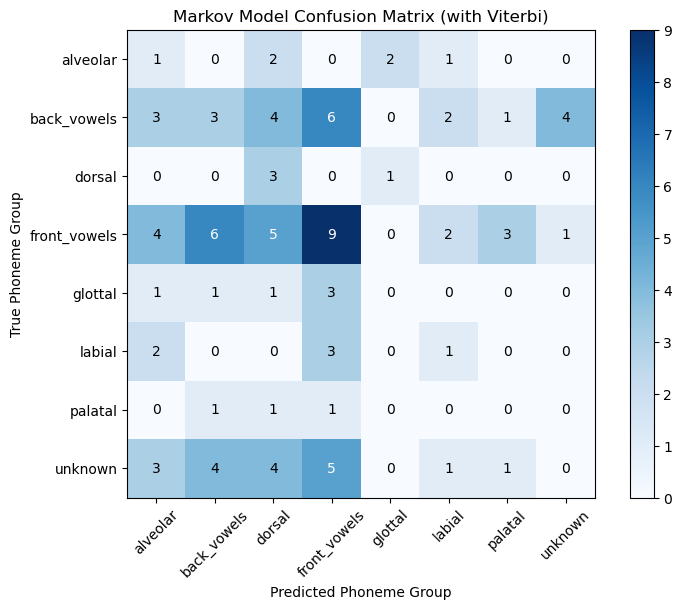

Confusion matrix saved to ./results\markov_model\confusion_matrix.png


In [22]:
# Visualize transition matrix
try:
    markov_model.visualize_transitions()
    print("Transition matrix saved")
except Exception as e:
    print(f"Error visualizing transitions: {e}")

# Plot confusion matrix
if eval_viterbi is not None:
    import matplotlib.pyplot as plt
    
    conf_matrix = eval_viterbi['confusion_matrix']
    labels = list(markov_model.group_encoder.classes_)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    plt.title('Markov Model Confusion Matrix (with Viterbi)')
    plt.colorbar()
    
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    
    # Add text annotations
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True Phoneme Group')
    plt.xlabel('Predicted Phoneme Group')
    
    save_path = os.path.join(markov_model.output_dir, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix saved to {save_path}")

In [23]:
# error analysis
if eval_viterbi is not None:
    # Find most confused pairs
    conf_matrix = eval_viterbi['confusion_matrix']
    labels = list(markov_model.group_encoder.classes_)
    
    confusion_pairs = []
    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            if i != j and conf_matrix[i, j] > 0:
                confusion_pairs.append((true_label, pred_label, conf_matrix[i, j]))
    
    # Sort by frequency
    confusion_pairs.sort(key=lambda x: x[2], reverse=True)
    
    print("\nTop 10 confusion pairs:")
    for true_label, pred_label, count in confusion_pairs[:10]:
        print(f"  {true_label} → {pred_label}: {int(count)} times")


Top 10 confusion pairs:
  back_vowels → front_vowels: 6 times
  front_vowels → back_vowels: 6 times
  front_vowels → dorsal: 5 times
  unknown → front_vowels: 5 times
  back_vowels → dorsal: 4 times
  back_vowels → unknown: 4 times
  front_vowels → alveolar: 4 times
  unknown → back_vowels: 4 times
  unknown → dorsal: 4 times
  back_vowels → alveolar: 3 times


In [24]:
# summary

summary = {
    'total_train_samples': len(train['features']),
    'total_test_samples': len(test['features']),
    'unique_train_phonemes': len(set(train['phoneme_labels'])),
    'unique_test_phonemes': len(set(test['phoneme_labels'])),
    'unknown_train_remaining': train['phoneme_labels'].count('?'),
    'unknown_test_remaining': test['phoneme_labels'].count('?'),
}

if eval_independent is not None:
    summary['accuracy_independent'] = eval_independent['accuracy']

if eval_viterbi is not None:
    summary['accuracy_viterbi'] = eval_viterbi['accuracy']

print("\nFinal summary:")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Save summary
import json
summary_path = os.path.join(markov_model.output_dir, 'training_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=4)
print(f"\nSummary saved to {summary_path}")


Final summary:
  total_train_samples: 160
  total_test_samples: 96
  unique_train_phonemes: 36
  unique_test_phonemes: 27
  unknown_train_remaining: 0
  unknown_test_remaining: 10
  accuracy_independent: 0.1771
  accuracy_viterbi: 0.1771

Summary saved to ./results\markov_model\training_summary.json


In [25]:
from phoneme_clustering_analysis import PhonemeClusteringAnalysis
markov_predictions, _ = markov_model.predict(test['features'], use_viterbi=True)
analyzer = PhonemeClusteringAnalysis(phonetic_dict=detector.phonetic_dict)

NameError: name 'DebugMixin' is not defined

In [ ]:
# 1. Quick check: See which groups are confused
cm, accuracies = analyzer.analyze_confusion_patterns(
    test['phoneme_labels'],
    markov_predictions,
    'articulation_place'  # Your current grouping
)

In [ ]:
print("\nProblem areas:")
for group, acc in accuracies.items():
    if acc < 0.5:  # Groups with <50% accuracy
        print(f"  {group}: {acc:.2%}")

In [ ]:
# 2. Test if other groupings would work better
results = analyzer.test_alternative_groupings(
    train['features'][:500],  # Use subset for speed
    train['phoneme_labels'][:500]
)


In [ ]:
# 3. See how phonemes actually cluster in your EEG space
analyzer.visualize_phoneme_space(
    test['features'][:200],
    test['phoneme_labels'][:200],
    method='pca',
    grouping='articulation_place'
)

In [ ]:
# 4. Discover what grouping your EEG data naturally suggests
natural_clusters = analyzer.hierarchical_clustering_analysis(
    train['features'][:500],
    train['phoneme_labels'][:500],
    n_clusters_to_try=[4, 6, 8]
)

In [ ]:
# 1. Check class distribution in training
from collections import Counter

# Map training labels to groups
train_groups = []
for label in train['phoneme_labels']:
    if label == '?':
        train_groups.append('unknown')
    else:
        group = markov_model.phoneme_to_group.get(label, 'unknown')
        train_groups.append(group)

print("Training group distribution:")
group_counts = Counter(train_groups)
for group, count in group_counts.most_common():
    print(f"  {group}: {count} ({count/len(train_groups)*100:.1f}%)")

# 2. Check what the acoustic model learned
print("\nAcoustic model class probabilities:")
if hasattr(markov_model.acoustic_classifier, 'class_prior_'):
    for i, prob in enumerate(markov_model.acoustic_classifier.class_prior_):
        print(f"  {markov_model.group_encoder.classes_[i]}: {prob:.3f}")

In [ ]:
def generate_word_segments_dict(custom_decoder, participant_ids=None):
    """
    Generate word_segments_dict for all participants or specific ones.
    
    Parameters:
    -----------
    custom_decoder : CustomBrainAudioDecoder
        Your decoder instance
    participant_ids : list or None
        List of participant IDs to process. If None, processes all.
    
    Returns:
    --------
    word_segments_dict : dict
        Dictionary mapping participant_id to word segments
    """
    word_segments_dict = {}
    
    # If no participant IDs specified, use all available
    if participant_ids is None:
        participant_ids = [f'sub-{i:02d}' for i in range(1, 11)]
    
    for participant_id in participant_ids:
        try:
            print(f"Segmenting data for {participant_id}...")
            
            # Call segment_data_by_words for this participant
            word_segments = custom_decoder.segment_data_by_words(
                participant_id=participant_id,
                pre_onset_ms=200,      # Time before word onset
                post_offset_ms=200,    # Time after word offset
                min_word_freq=1,       # Minimum word frequency
                handle_overlaps='adjust'  # How to handle overlapping segments
            )
            
            if word_segments:
                word_segments_dict[participant_id] = word_segments
                print(f"✓ Segmented {len(word_segments['words'])} unique words for {participant_id}")
            else:
                print(f"⚠️ No segments found for {participant_id}")
                
        except Exception as e:
            print(f"Error segmenting data for {participant_id}: {e}")
    
    return word_segments_dict

In [ ]:
def validate_phoneme_segmentation(detector, word_segments_dict, phonetic_dict):
    """
    Comprehensive validation of phoneme segmentation quality
    """
    validation_results = {
        'segmentation_accuracy': {},
        'boundary_consistency': {},
        'duration_analysis': {},
        'alignment_issues': []
    }
    
    # 1. Check if number of detected segments matches expected phonemes
    print("=" * 60)
    print("1. SEGMENTATION COUNT VALIDATION")
    print("=" * 60)
    
    correct_counts = 0
    total_words = 0
    
    for participant_id, segments in word_segments_dict.items():
        for word, word_info in segments.get('words', {}).items():
            if word in phonetic_dict:
                expected_phonemes = phonetic_dict.count_phonemes(word)
                
                for instance in word_info.get('instances', []):
                    if 'spectrogram_segment' in instance:
                        # Detect boundaries for this instance
                        result = detector.detect_boundaries(
                            instance['spectrogram_segment'],
                            word=word
                        )
                        
                        detected_segments = len(result['segments'])
                        total_words += 1
                        
                        if detected_segments == expected_phonemes:
                            correct_counts += 1
                        else:
                            validation_results['alignment_issues'].append({
                                'word': word,
                                'participant': participant_id,
                                'expected': expected_phonemes,
                                'detected': detected_segments
                            })
    
    accuracy = correct_counts / total_words if total_words > 0 else 0
    validation_results['segmentation_accuracy']['overall'] = accuracy
    print(f"Segmentation accuracy: {accuracy:.2%} ({correct_counts}/{total_words})")
    
    # 2. Check phoneme duration consistency
    print("\n" + "=" * 60)
    print("2. PHONEME DURATION ANALYSIS")
    print("=" * 60)
    
    phoneme_durations = {}
    
    for participant_id, segments in word_segments_dict.items():
        for word, word_info in segments.get('words', {}).items():
            if word in phonetic_dict:
                phonemes = phonetic_dict.extract_phonemes(word)
                
                for instance in word_info.get('instances', []):
                    if 'spectrogram_segment' in instance:
                        result = detector.detect_boundaries(
                            instance['spectrogram_segment'],
                            word=word
                        )
                        
                        if len(result['segments']) == len(phonemes):
                            for phoneme, segment in zip(phonemes, result['segments']):
                                if phoneme not in phoneme_durations:
                                    phoneme_durations[phoneme] = []
                                phoneme_durations[phoneme].append(segment.shape[0])
    
    # Analyze duration consistency
    for phoneme, durations in phoneme_durations.items():
        if len(durations) > 1:
            mean_dur = np.mean(durations)
            std_dur = np.std(durations)
            cv = std_dur / mean_dur if mean_dur > 0 else float('inf')
            
            validation_results['duration_analysis'][phoneme] = {
                'mean': mean_dur,
                'std': std_dur,
                'cv': cv,
                'n_samples': len(durations)
            }
            
            if cv > 0.5:  # High variability
                print(f"⚠️ High variability for '{phoneme}': CV={cv:.2f}")
    
    # 3. Check boundary detection consistency across same words
    print("\n" + "=" * 60)
    print("3. BOUNDARY CONSISTENCY CHECK")
    print("=" * 60)
    
    word_boundaries = {}
    
    for participant_id, segments in word_segments_dict.items():
        for word, word_info in segments.get('words', {}).items():
            if word not in word_boundaries:
                word_boundaries[word] = []
            
            for instance in word_info.get('instances', []):
                if 'spectrogram_segment' in instance:
                    result = detector.detect_boundaries(
                        instance['spectrogram_segment'],
                        word=word
                    )
                    
                    # Normalize boundaries by total length
                    total_frames = instance['spectrogram_segment'].shape[0]
                    normalized = result['boundaries'] / total_frames
                    word_boundaries[word].append(normalized)
    
    # Analyze consistency
    for word, boundaries_list in word_boundaries.items():
        if len(boundaries_list) > 1:
            # Calculate variance in boundary positions
            boundaries_array = np.array([b for b in boundaries_list if len(b) == len(boundaries_list[0])])
            
            if len(boundaries_array) > 1:
                mean_boundaries = np.mean(boundaries_array, axis=0)
                std_boundaries = np.std(boundaries_array, axis=0)
                
                validation_results['boundary_consistency'][word] = {
                    'mean_positions': mean_boundaries.tolist(),
                    'std_positions': std_boundaries.tolist(),
                    'max_std': np.max(std_boundaries)
                }
                
                if np.max(std_boundaries) > 0.1:
                    print(f"⚠️ Inconsistent boundaries for '{word}': max std={np.max(std_boundaries):.3f}")
    
    return validation_results


def check_data_balance(train_accumulated_data, test_accumulated_data):
    """
    Check class balance and data distribution
    """
    from collections import Counter
    
    print("=" * 60)
    print("DATA BALANCE ANALYSIS")
    print("=" * 60)
    
    # Analyze training data
    train_labels = train_accumulated_data['phoneme_labels']
    train_counter = Counter(train_labels)
    
    print("\nTraining data distribution:")
    for phoneme, count in train_counter.most_common(10):
        print(f"  {phoneme}: {count} ({count/len(train_labels)*100:.1f}%)")
    
    # Check for rare classes
    rare_threshold = 5
    rare_phonemes = [p for p, c in train_counter.items() if c < rare_threshold]
    if rare_phonemes:
        print(f"\n⚠️ Warning: {len(rare_phonemes)} phonemes with < {rare_threshold} samples")
        print(f"   Rare phonemes: {rare_phonemes[:10]}")
    
    # Check test data
    test_labels = test_accumulated_data['phoneme_labels']
    test_counter = Counter(test_labels)
    
    # Check for unseen phonemes in test
    unseen = set(test_counter.keys()) - set(train_counter.keys())
    if unseen:
        print(f"\n⚠️ Test set contains {len(unseen)} unseen phonemes: {list(unseen)[:10]}")
    
    # Calculate class imbalance ratio
    max_count = max(train_counter.values())
    min_count = min(train_counter.values())
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}")
    if imbalance_ratio > 10:
        print("⚠️ Severe class imbalance detected!")
    
    return {
        'train_distribution': dict(train_counter),
        'test_distribution': dict(test_counter),
        'rare_phonemes': rare_phonemes,
        'unseen_phonemes': list(unseen),
        'imbalance_ratio': imbalance_ratio
    }


def validate_feature_extraction(train_accumulated_data):
    """
    Validate feature extraction quality
    """
    print("=" * 60)
    print("FEATURE EXTRACTION VALIDATION")
    print("=" * 60)
    
    features = train_accumulated_data['features']
    
    issues = []
    
    # 1. Check for NaN/Inf values
    nan_count = 0
    inf_count = 0
    zero_variance_count = 0
    
    for i, feat in enumerate(features):
        if np.any(np.isnan(feat)):
            nan_count += 1
            issues.append(f"Sample {i}: Contains NaN")
        
        if np.any(np.isinf(feat)):
            inf_count += 1
            issues.append(f"Sample {i}: Contains Inf")
        
        # Check for zero variance features
        if feat.ndim > 1:
            variances = np.var(feat, axis=0)
            if np.any(variances < 1e-10):
                zero_variance_count += 1
    
    print(f"NaN samples: {nan_count}/{len(features)}")
    print(f"Inf samples: {inf_count}/{len(features)}")
    print(f"Zero variance features: {zero_variance_count}/{len(features)}")
    
    # 2. Check feature dimensions
    shapes = [f.shape for f in features]
    unique_shapes = set(shapes)
    
    if len(unique_shapes) > 1:
        print(f"\n⚠️ Inconsistent feature shapes detected:")
        for shape in unique_shapes:
            count = shapes.count(shape)
            print(f"  Shape {shape}: {count} samples")
    
    # 3. Check feature magnitudes
    magnitudes = []
    for feat in features[:100]:  # Sample first 100
        if feat.size > 0:
            magnitudes.append(np.mean(np.abs(feat)))
    
    mean_magnitude = np.mean(magnitudes)
    std_magnitude = np.std(magnitudes)
    
    print(f"\nFeature magnitudes:")
    print(f"  Mean: {mean_magnitude:.6f}")
    print(f"  Std: {std_magnitude:.6f}")
    
    if mean_magnitude < 1e-6:
        print("⚠️ Features may be too small - consider scaling")
    elif mean_magnitude > 1e6:
        print("⚠️ Features may be too large - consider normalization")
    
    return {
        'nan_count': nan_count,
        'inf_count': inf_count,
        'zero_variance_count': zero_variance_count,
        'unique_shapes': list(unique_shapes),
        'magnitude_stats': {
            'mean': mean_magnitude,
            'std': std_magnitude
        }
    }


def validate_participant_split(split_result):
    """
    Validate train/test split quality
    """
    print("=" * 60)
    print("TRAIN/TEST SPLIT VALIDATION")
    print("=" * 60)
    
    train = split_result['train']
    test = split_result['test']
    
    # 1. Check participant overlap
    train_participants = set(train.keys())
    test_participants = set(test.keys())
    
    print(f"Train participants: {len(train_participants)}")
    print(f"Test participants: {len(test_participants)}")
    
    # 2. Check word distribution
    train_words = set()
    test_words = set()
    
    for participant_data in train.values():
        train_words.update(participant_data.keys())
    
    for participant_data in test.values():
        test_words.update(participant_data.keys())
    
    word_overlap = train_words & test_words
    unique_test_words = test_words - train_words
    
    print(f"\nWord statistics:")
    print(f"  Train words: {len(train_words)}")
    print(f"  Test words: {len(test_words)}")
    print(f"  Overlapping words: {len(word_overlap)}")
    print(f"  Unique test words: {len(unique_test_words)}")
    
    if len(unique_test_words) > 0:
        print(f"  ⚠️ Test has {len(unique_test_words)} unseen words: {list(unique_test_words)[:5]}")
    
    # 3. Check instance counts
    train_instances = sum(
        len(instances) for participant_data in train.values() 
        for instances in participant_data.values()
    )
    
    test_instances = sum(
        len(instances) for participant_data in test.values() 
        for instances in participant_data.values()
    )
    
    split_ratio = train_instances / (train_instances + test_instances)
    
    print(f"\nInstance distribution:")
    print(f"  Train instances: {train_instances}")
    print(f"  Test instances: {test_instances}")
    print(f"  Train ratio: {split_ratio:.2%}")
    
    return {
        'train_participants': list(train_participants),
        'test_participants': list(test_participants),
        'train_words': list(train_words),
        'test_words': list(test_words),
        'unique_test_words': list(unique_test_words),
        'split_ratio': split_ratio
    }


# Usage example:
def run_all_validations(detector, split_result, train_data, test_data, word_segments_dict):
    """
    Run all validation checks
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE DATA VALIDATION REPORT")
    print("="*80 + "\n")
    
    # 1. Validate segmentation
    segmentation_results = validate_phoneme_segmentation(
        detector, 
        word_segments_dict, 
        detector.phonetic_dict
    )
    
    # 2. Check data balance
    balance_results = check_data_balance(train_data, test_data)
    
    # 3. Validate features
    feature_results = validate_feature_extraction(train_data)
    
    # 4. Validate split
    split_results = validate_participant_split(split_result)
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY OF ISSUES")
    print("="*80)
    
    issues_found = []
    
    if segmentation_results['segmentation_accuracy']['overall'] < 0.7:
        issues_found.append(f"Low segmentation accuracy: {segmentation_results['segmentation_accuracy']['overall']:.2%}")
    
    if balance_results['imbalance_ratio'] > 10:
        issues_found.append(f"Severe class imbalance: {balance_results['imbalance_ratio']:.1f}x")
    
    if feature_results['nan_count'] > 0:
        issues_found.append(f"NaN values in {feature_results['nan_count']} samples")
    
    if len(balance_results['unseen_phonemes']) > 0:
        issues_found.append(f"{len(balance_results['unseen_phonemes'])} unseen phonemes in test")
    
    if issues_found:
        print("\n⚠️ Critical issues detected:")
        for issue in issues_found:
            print(f"  • {issue}")
    else:
        print("\n✓ No critical issues detected")
    
    return {
        'segmentation': segmentation_results,
        'balance': balance_results,
        'features': feature_results,
        'split': split_results,
        'issues': issues_found
    }

In [ ]:
word_segments_dict = generate_word_segments_dict(custom_decoder)

In [ ]:
validate_phoneme_segmentation(detector, word_segments_dict, phonetic_dict)